In [1]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score



In [2]:
# Load Iris dataset
iris = load_iris()


In [3]:
# Features and target
X = iris.data
y = iris.target

# Dataset information
print(X.shape)
print(iris.target_names)

(150, 4)
['setosa' 'versicolor' 'virginica']


In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)


In [6]:
# Train the model
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [7]:

# Make predictions
y_pred = knn.predict(X_test)

In [8]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [9]:
import pandas as pd

# Target names
target_names = iris.target_names

# Create results table
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [10]:
# Map numeric labels to flower names
results["Actual Name"] = results["Actual"].apply(
    lambda x: target_names[x]
)

results["Predicted Name"] = results["Predicted"].apply(
    lambda x: target_names[x]
)


# Separate correct and wrong predictions
correct_predictions = results[
    results["Actual"] == results["Predicted"]
]

wrong_predictions = results[
    results["Actual"] != results["Predicted"]
]


In [11]:
# Print correct predictions
print("Correct predictions:")
print(
    correct_predictions[["Actual Name", "Predicted Name"]]
)


# Print wrong predictions
print("\nWrong predictions:")

Correct predictions:
   Actual Name Predicted Name
0   versicolor     versicolor
1       setosa         setosa
2    virginica      virginica
3   versicolor     versicolor
4   versicolor     versicolor
5       setosa         setosa
6   versicolor     versicolor
7    virginica      virginica
8   versicolor     versicolor
9   versicolor     versicolor
10   virginica      virginica
11      setosa         setosa
12      setosa         setosa
13      setosa         setosa
14      setosa         setosa
15  versicolor     versicolor
16   virginica      virginica
17  versicolor     versicolor
18  versicolor     versicolor
19   virginica      virginica
20      setosa         setosa
21   virginica      virginica
22      setosa         setosa
23   virginica      virginica
24   virginica      virginica
25   virginica      virginica
26   virginica      virginica
27   virginica      virginica
28      setosa         setosa
29      setosa         setosa

Wrong predictions:


In [12]:
if len(wrong_predictions) == 0:
    print("No wrong predictions!")
else:
    print(
        wrong_predictions[["Actual Name", "Predicted Name"]]
    )

No wrong predictions!


[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


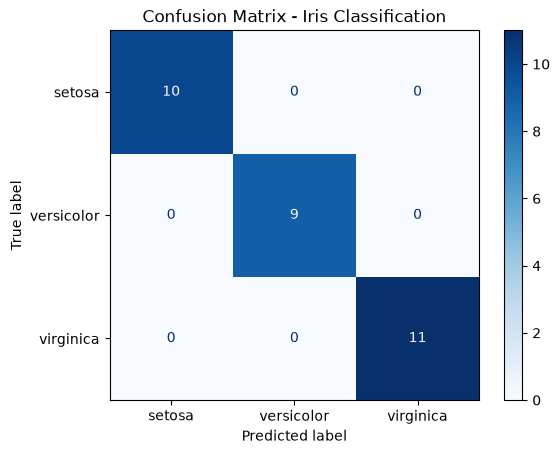

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(results["Actual"], results["Predicted"])
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Iris Classification")
plt.show()